<a href="https://colab.research.google.com/github/moloruns/Olorunsola_DSPN_S26/blob/master/Exercise16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 16: Model selection

This homework is designed to give you practice implementing model selection techniques, including best subset selection and forward/backward stepwise selection.

You won't need to load in any data for this homework, we will be simulating our own.

---
## 1. Best subset selection (4 points)

In this question, we will first generate simulated data, and then use it to perform best subset selection.

a) Use `rnorm()` to generate a dataset including a predictor $X$ of length $n = 100$ and a noise vector $\epsilon$ of length $n = 100$. Generate data for a response variable $Y$ of length $n = 100$ according to the model

$Y = \beta_0 + \beta_1X + \beta_2X^2 + \beta_3X^3 + \epsilon$

where $\beta_0$, $\beta_1$, $\beta_2$, and $\beta_3$ are constants of your choice.


In [57]:
set.seed(15)
X <- rnorm(100)
epsilon <- rnorm(100)

# betas
for(i in 1:4){
  beta0 <- rnorm(1)
  beta1 <- rnorm(1)
  beta2 <- rnorm(1)
  beta3 <- rnorm(1)
}

# Y
Y <- beta0 + beta1*X + beta2*X^2 + beta3*X^3 + epsilon

X <- data.frame(X, X^2, X^3, X^4, X^5, X^6, X^7, X^8, X^9, X^10)

b) Use `regsubsets()` to perform best subset selection to determine the best model that contains the predictor variables $X$, $X^2$, . . . , $X^{10}$. Print the model summary.

In [69]:
library(leaps)
regfit <- regsubsets(Y ~ X + X.2 + X.3 + X.4 + X.5 + X.6 + X.7 + X.8 + X.9 + X.10,
                     data = X, nvmax=10)

(sumfit <- summary(regfit))



Subset selection object
Call: regsubsets.formula(Y ~ X + X.2 + X.3 + X.4 + X.5 + X.6 + X.7 + 
    X.8 + X.9 + X.10, data = X, nvmax = 10)
10 Variables  (and intercept)
     Forced in Forced out
X        FALSE      FALSE
X.2      FALSE      FALSE
X.3      FALSE      FALSE
X.4      FALSE      FALSE
X.5      FALSE      FALSE
X.6      FALSE      FALSE
X.7      FALSE      FALSE
X.8      FALSE      FALSE
X.9      FALSE      FALSE
X.10     FALSE      FALSE
1 subsets of each size up to 10
Selection Algorithm: exhaustive
          X   X.2 X.3 X.4 X.5 X.6 X.7 X.8 X.9 X.10
1  ( 1 )  " " " " "*" " " " " " " " " " " " " " " 
2  ( 1 )  " " "*" "*" " " " " " " " " " " " " " " 
3  ( 1 )  "*" "*" "*" " " " " " " " " " " " " " " 
4  ( 1 )  "*" "*" "*" " " " " "*" " " " " " " " " 
5  ( 1 )  "*" "*" "*" " " "*" "*" " " " " " " " " 
6  ( 1 )  "*" " " "*" "*" " " "*" " " "*" " " "*" 
7  ( 1 )  "*" " " "*" "*" "*" "*" " " "*" " " "*" 
8  ( 1 )  "*" " " "*" "*" " " "*" "*" "*" "*" "*" 
9  ( 1 )  "*" " " "*" "

In [ ]:
# Note: if your model summary doesn't show up when viewing your notebook on github, copy and paste the output below.
# Otherwise you can either delete this cell or leave it blank.

```
# paste here

```

c) Plot the Mallows' Cp, Bayesian Information Criteria (BIC) and the adjusted coefficient of determination, $R^2$, for each model tested. Based on each criterion, identify the best model size. Report the coefficients of the best model.

[1] 6

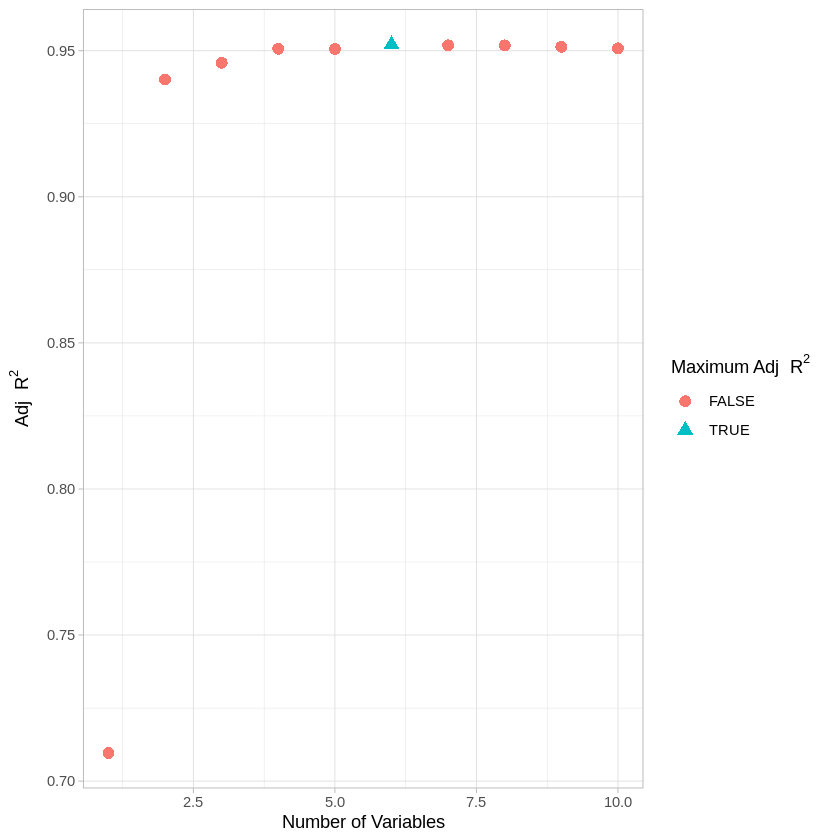

[1] 6

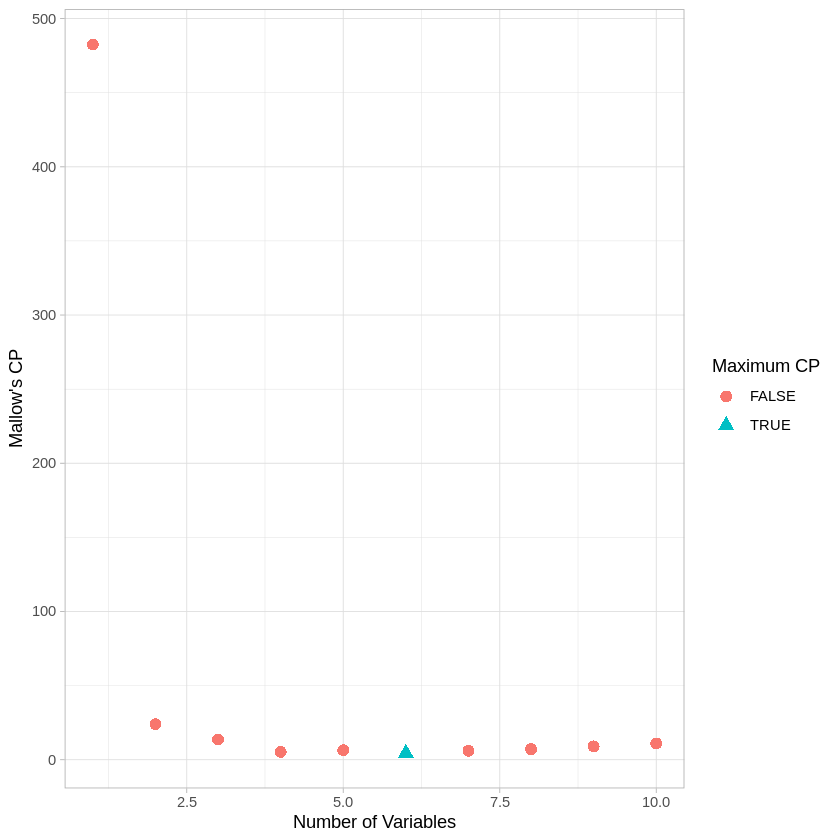

[1] 4

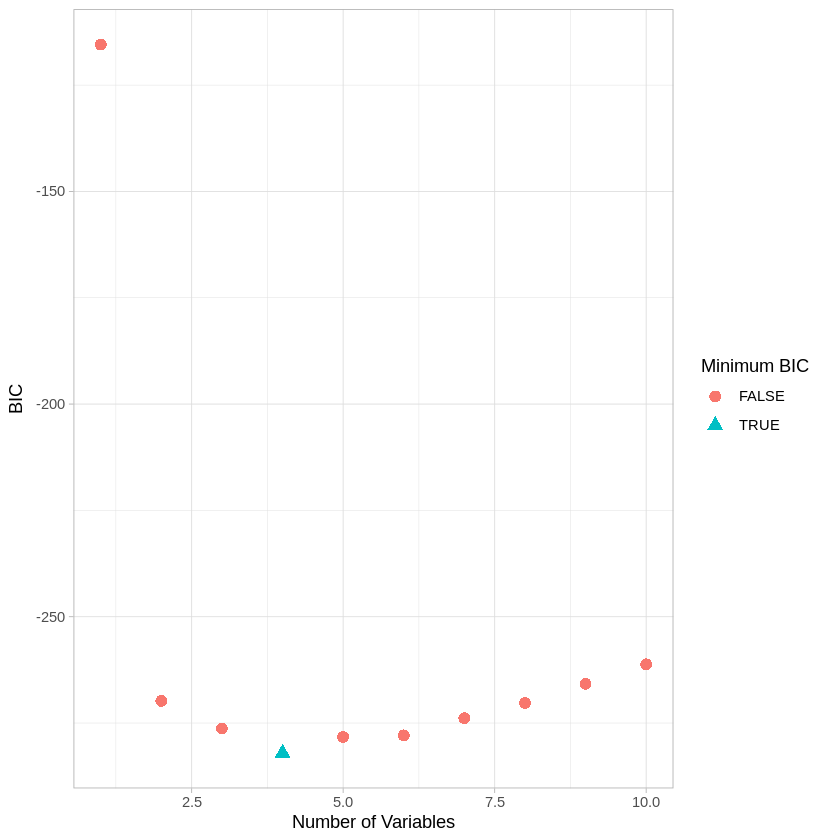

In [78]:
library(tidyverse)

numvar = 1:length(sumfit$rss)
allfalse = rep(FALSE,length(sumfit$rss))

# adjr2
adjr2.df <- data.frame(numvar = numvar, adjr2 <- sumfit$adjr2, maxadjr2 <- allfalse)
adjr2.df$maxadjr2[which.max(sumfit$adjr2)] <- TRUE
ggplot(adjr2.df,aes(x=numvar,y=adjr2,shape=maxadjr2,col=maxadjr2)) +
    geom_point(size=3) + theme_light() +
    labs(x = "Number of Variables", y = 'Adj'~R^2, color='Maximum Adj'~R^2, shape='Maximum Adj'~R^2)
which.max(sumfit$adjr2)


# mallow's cp
cp.df <- data.frame(numvar = numvar, cp <- sumfit$cp, mincp <- allfalse)
cp.df$mincp[which.min(sumfit$cp)] <- TRUE
ggplot(cp.df,aes(x=numvar,y=cp,shape=mincp,col=mincp)) +
    geom_point(size=3) + theme_light() +
    labs(x = "Number of Variables", y = "Mallow's CP", color="Maximum CP", shape="Maximum CP")
which.min(sumfit$cp)


# bic
bic.df <- data.frame(numvar = numvar,bic <- sumfit$bic, minbic <- allfalse)
bic.df$minbic[which.min(sumfit$bic)] <- TRUE
ggplot(bic.df,aes(x=numvar,y=bic,shape=minbic,col=minbic)) +
    geom_point(size=3) + theme_light() +
    labs(x = "Number of Variables", y = "BIC", color="Minimum BIC", shape="Minimum BIC")
which.min(sumfit$bic)



> Given that Mallow's CP and adjusted R^2 both agree on optimal model size, the best model size is 6 predictors (only BIC reported a different size at 4).
>

---
## 2. Forward and backwards stepwise selection (3 points)

Using the same simulated data from question 1, use forward stepwise selection, and backwards stepwise selections to identify the best model under each criterion. Again, for both model selection methods, plot the Mallows' Cp, Bayesian Information Criteria (BIC) and the adjusted coefficient of determination, $R^2$, for each model tested. Report the coefficients of the best model.

a) Forward stepwise selection:

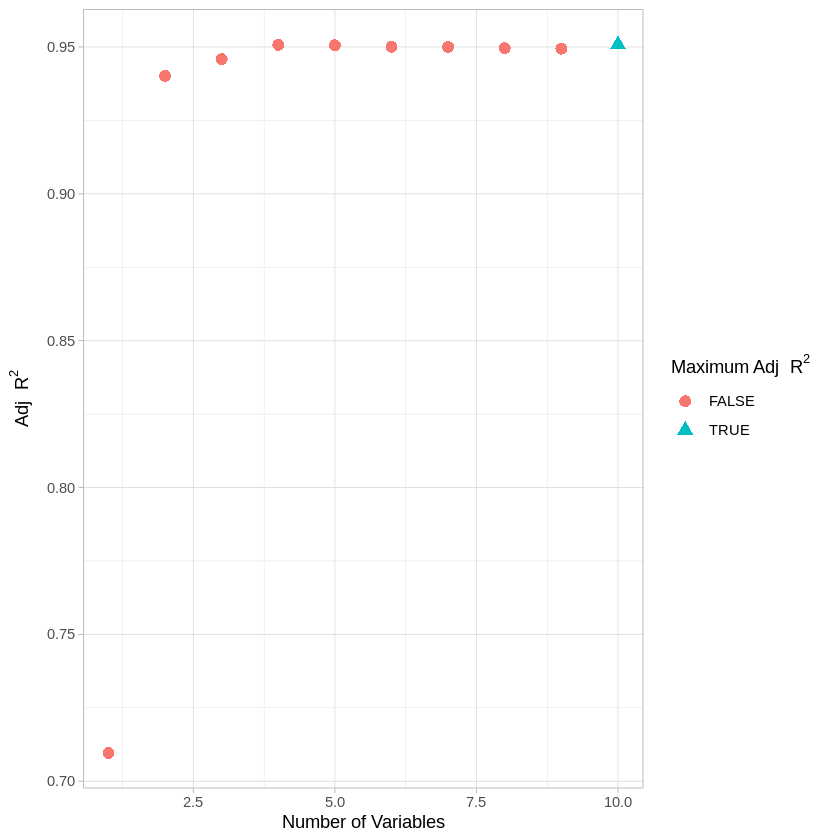

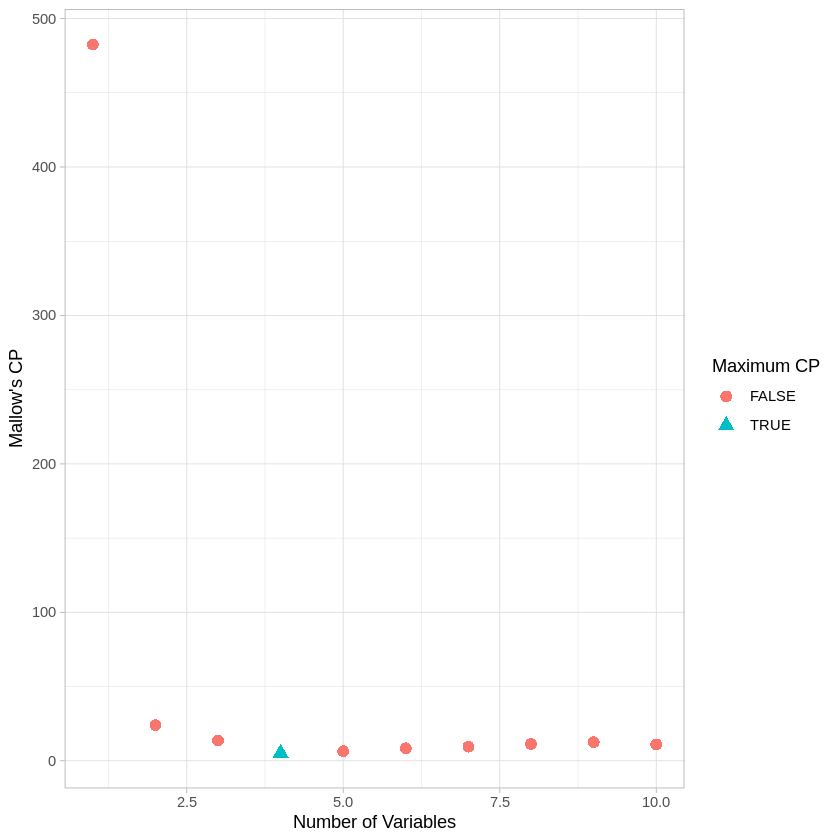

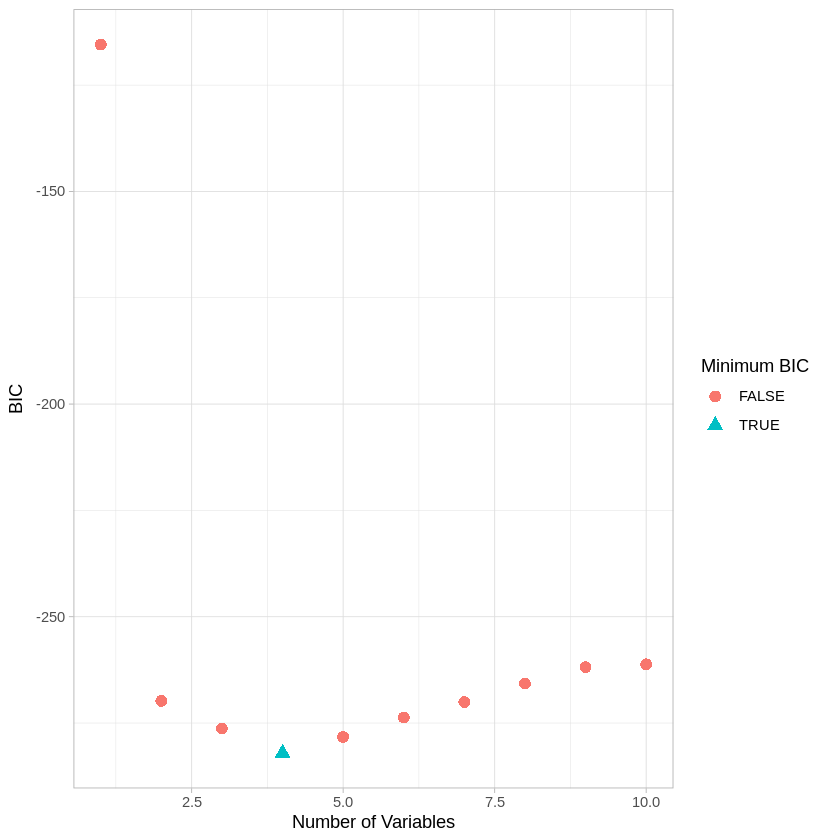

In [81]:
regfit.f <- regsubsets(Y ~ X + X.2 + X.3 + X.4 + X.5 + X.6 + X.7 + X.8 + X.9 + X.10,
                         data = X, nvmax = 10, method = "forward")

sumfit.f <- summary(regfit.f)

# adjr2
adjr2.df <- data.frame(numvar = numvar, adjr2 <- sumfit.f$adjr2, maxadjr2 <- allfalse)
adjr2.df$maxadjr2[which.max(sumfit.f$adjr2)] <- TRUE
ggplot(adjr2.df,aes(x=numvar,y=adjr2,shape=maxadjr2,col=maxadjr2)) +
    geom_point(size=3) + theme_light() +
    labs(x = "Number of Variables", y = 'Adj'~R^2, color='Maximum Adj'~R^2, shape='Maximum Adj'~R^2)

# mallow's cp
cp.df <- data.frame(numvar = numvar, cp <- sumfit.f$cp, mincp <- allfalse)
cp.df$mincp[which.min(sumfit.f$cp)] <- TRUE
ggplot(cp.df,aes(x=numvar,y=cp,shape=mincp,col=mincp)) +
    geom_point(size=3) + theme_light() +
    labs(x = "Number of Variables", y = "Mallow's CP", color="Maximum CP", shape="Maximum CP")

# bic
bic.df <- data.frame(numvar = numvar,bic <- sumfit.f$bic, minbic <- allfalse)
bic.df$minbic[which.min(sumfit.f$bic)] <- TRUE
ggplot(bic.df,aes(x=numvar,y=bic,shape=minbic,col=minbic)) +
    geom_point(size=3) + theme_light() +
    labs(x = "Number of Variables", y = "BIC", color="Minimum BIC", shape="Minimum BIC")

In [ ]:
# Note: if your model summary doesn't show up when viewing your notebook on github, copy and paste the output below.
# Otherwise you can either delete this cell or leave it blank.

```
# paste here

```

b) Backwards stepwise selection:

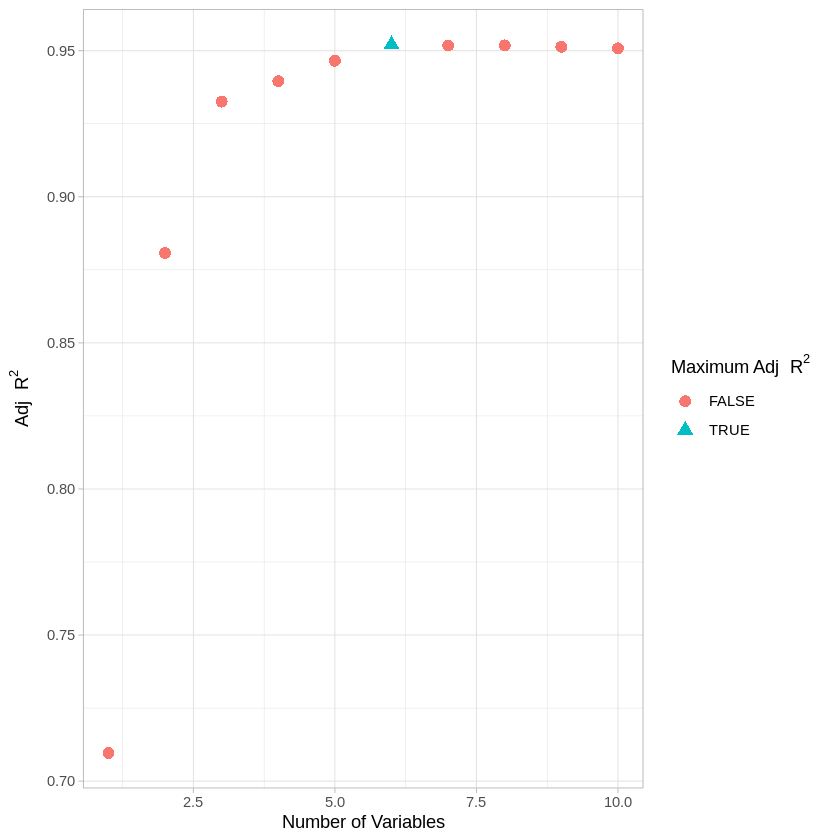

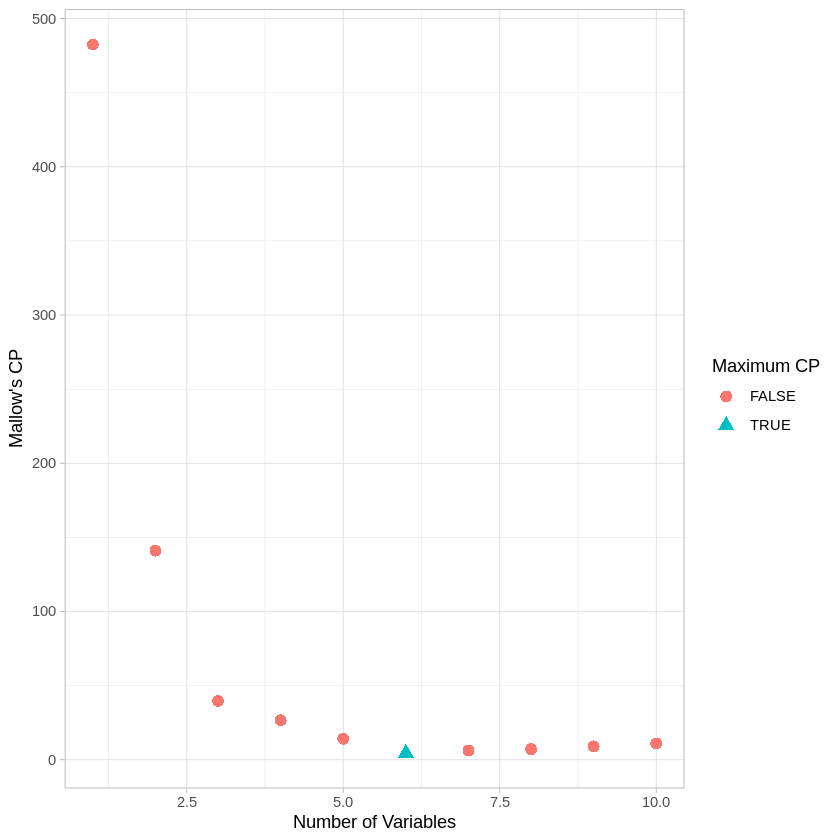

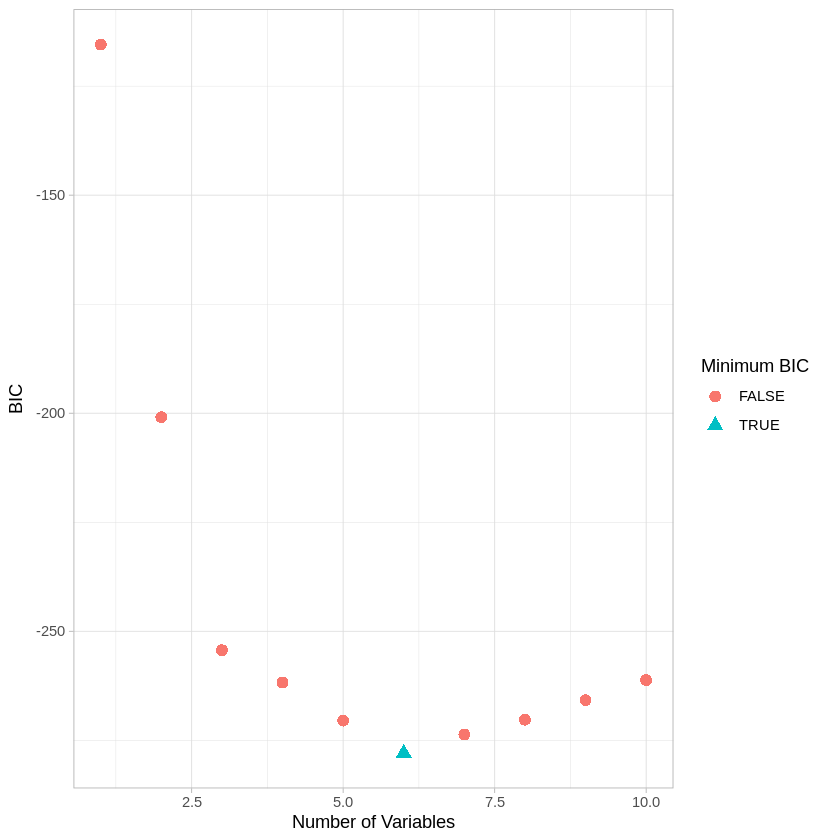

In [82]:
regfit.b <- regsubsets(Y ~ X + X.2 + X.3 + X.4 + X.5 + X.6 + X.7 + X.8 + X.9 + X.10,
                         data = X, nvmax = 10, method = "backward")

sumfit.b <- summary(regfit.b)

# adjr2
adjr2.df <- data.frame(numvar = numvar, adjr2 <- sumfit.b$adjr2, maxadjr2 <- allfalse)
adjr2.df$maxadjr2[which.max(sumfit.b$adjr2)] <- TRUE
ggplot(adjr2.df,aes(x=numvar,y=adjr2,shape=maxadjr2,col=maxadjr2)) +
    geom_point(size=3) + theme_light() +
    labs(x = "Number of Variables", y = 'Adj'~R^2, color='Maximum Adj'~R^2, shape='Maximum Adj'~R^2)

# mallow's cp
cp.df <- data.frame(numvar = numvar, cp <- sumfit.b$cp, mincp <- allfalse)
cp.df$mincp[which.min(sumfit.b$cp)] <- TRUE
ggplot(cp.df,aes(x=numvar,y=cp,shape=mincp,col=mincp)) +
    geom_point(size=3) + theme_light() +
    labs(x = "Number of Variables", y = "Mallow's CP", color="Maximum CP", shape="Maximum CP")

# bic
bic.df <- data.frame(numvar = numvar,bic <- sumfit.b$bic, minbic <- allfalse)
bic.df$minbic[which.min(sumfit.b$bic)] <- TRUE
ggplot(bic.df,aes(x=numvar,y=bic,shape=minbic,col=minbic)) +
    geom_point(size=3) + theme_light() +
    labs(x = "Number of Variables", y = "BIC", color="Minimum BIC", shape="Minimum BIC")



In [ ]:
# Note: if your model summary doesn't show up when viewing your notebook on github, copy and paste the output below.
# Otherwise you can either delete this cell or leave it blank.

```
# paste here

```

c) Compare your results from parts a and b with those of question 1. Did the two methods select similar model sizes and predictors? If not, how did they differ?

> The popular result from question 1 is consistent with the results yielded in part b, as both suggest that the optimal size for this model is 6 predictors. On the other hand, we observed that the popular result from part a is consistent with the optimal size that was suggested by question 1's BIC criterion, that being 4.
>

---
## 3. Training and test error (3 points)

This question will explore the relationship between training and test error and the number of features included in a model. We will again use a simulated dataset.

a) Simulate dataset with features $p = 20$ and observations $n = 1,000$. Generate data for a response variable $Y$ according to the model

$Y = X\beta + \epsilon$

where $\beta$ is random with some elements that are exactly zero.

Split your simulated dataset into a training set containing $n=100$ observations and a test set containing $n=900$ observations.

In [88]:
set.seed(15)
n <- 1000
p <- 20

# beta; some 0
beta <- c(1.2, -0.8, 2.1, 0, 0.5, 0, -1.4, 0, 0.9, 0,
          0, 1.7, 0, -0.6, 0, 0, 1.1, 0, -0.3, 0)

# sim data

simulate.data <- function(n, p, beta, sd_epislon = 1) {
  X <- matrix(rnorm(n*p), nrow = n, ncol = p)
  epsilon <- rnorm(n, 0, sd_epislon)

  Y <- X %*% beta + epsilon

  df <- data.frame(Y = Y, X)
  return(df)
}

dat <- simulate.data(n, p, beta)

i <- sample(1:n, 100)
dat.train <- dat[i,]
dat.test <- dat[-i,]


b) Perform best subset selection on the training set, and plot the associated training and test set MSE for the best model of each size.

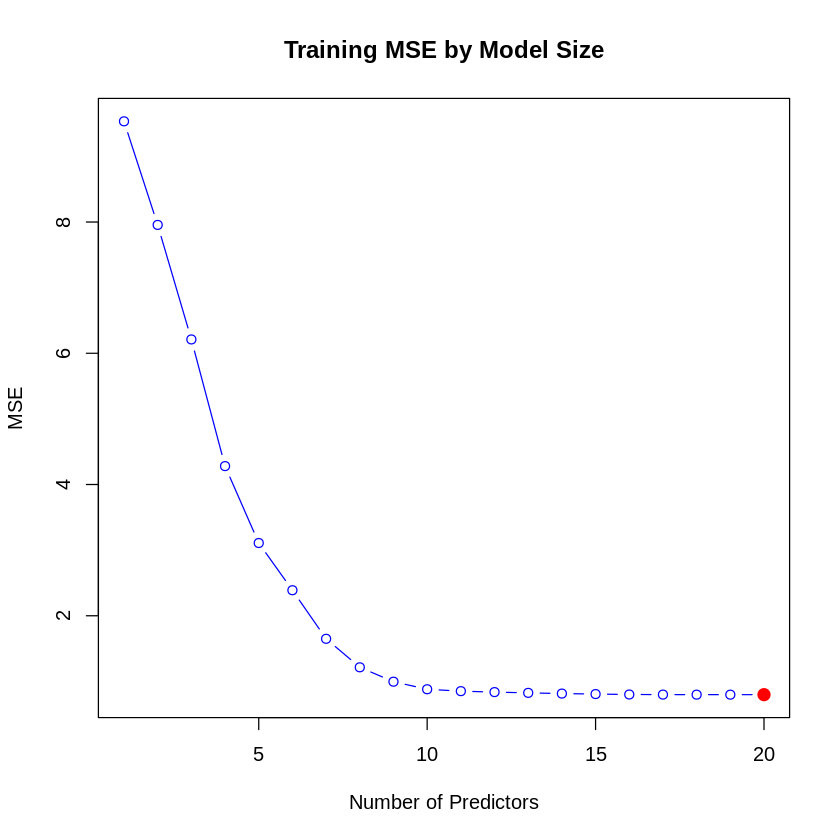

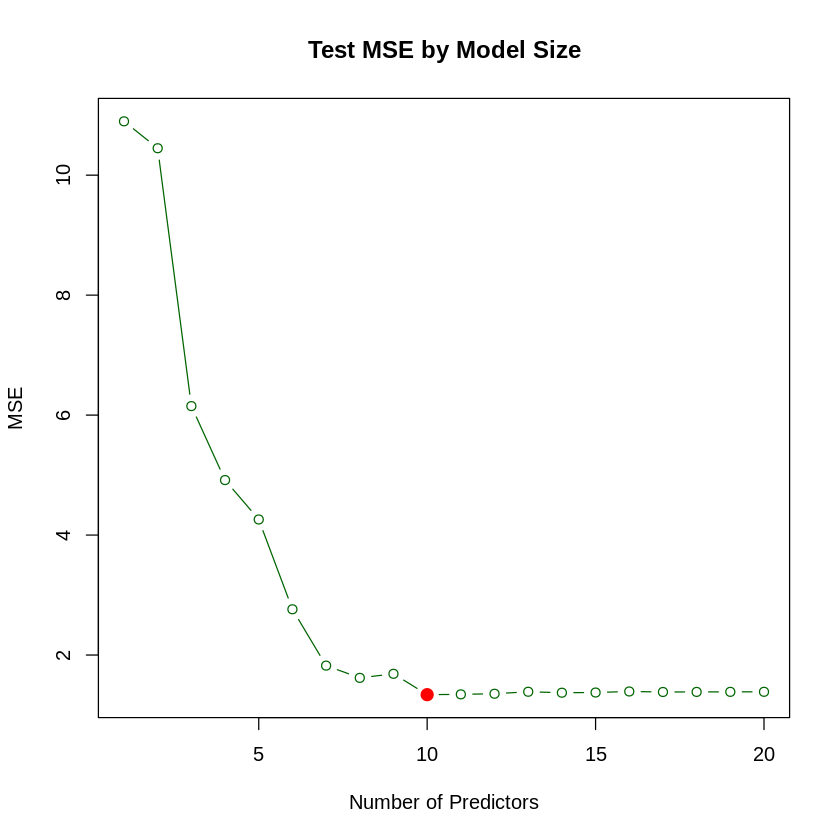

In [90]:
regfit.full <- regsubsets(Y ~ ., data = dat.train, nvmax = p)
sumfit <- summary(regfit.full)

predict.regsub <- function(mod, data, id) {
  form <- as.formula(mod$call[[2]])
  mat <- model.matrix(form, data)
  coefi <- coef(mod, id = id)
  x <- names(coefi)
  return(mat[,x] %*% coefi)
}

mse.train <- numeric(p)
mse.test <- numeric(p)

for (i in 1:p) {
  train.pred <- predict.regsub(regfit.full, dat.train, id = i)
  test.pred <- predict.regsub(regfit.full, dat.test, id = i)

  mse.train[i] <- mean((dat.train$Y - train.pred)^2)
  mse.test[i] <- mean((dat.test$Y - test.pred)^2)
}

plot(1:p, mse.train, type = "b", col = "blue",
     xlab = "Number of Predictors", ylab = "MSE",
     main = "Training MSE by Model Size")
points(which.min(mse.train), mse.train[which.min(mse.train)],
       col = "red", cex = 2, pch = 20)

plot(1:p, mse.test, type = "b", col = "darkgreen",
     xlab = "Number of Predictors", ylab = "MSE",
     main = "Test MSE by Model Size")
points(which.min(mse.test), mse.test[which.min(mse.test)],
       col = "red", cex = 2, pch = 20)

c) Identify the best model according to the test MSE. How does this model compare to the actual model used to simulate the dataset?

*Note: If the model identified contains only an intercept or all of the features, then generate a new dataset (i.e. repeat part a with a different random seed) until the test set MSE is minimized for an intermediate model size.*

In [91]:
which.min(mse.test)



[1] 10

> The best model according to test MSE has 10 predictors.
>

**DUE:** 11:59pm EST, April 2, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> no